
# Final Project: INFO6106 Neural Modeling Methods & Tools
# Predicting 1 Day in Advanced



# Lake Effect Precipitation Prediction using CNN and RNN

(1 day in Advance)

**Import necessary libraries**

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import date

import pickle
import cv2

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
import tensorflow as tf

In [4]:
print(tf.__version__)

2.13.1


In [5]:
from keras.models import Model
from keras.layers import Input, Conv3D, BatchNormalization, MaxPooling3D, Flatten, Dense, LSTM, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

## Read `meteorological_data` data

In [6]:
meteorological_data_original = pd.read_csv('meteorological_data.csv')

meteorological_data_full = meteorological_data_original.copy()
meteorological_data_full

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Wind_Direction_deg,Low_Cloud_Ht_ft,Visibility_mi,Atm_Press_hPa,Precip_in
0,2006-10-01 00:00:00,48.0,86.0,7,150,4100,10,984.0,0.00
1,2006-10-01 01:00:00,48.0,86.0,8,150,6000,10,983.7,0.00
2,2006-10-01 02:00:00,48.0,86.0,6,150,5500,10,982.7,0.00
3,2006-10-01 03:00:00,48.0,86.0,8,150,6000,10,982.0,0.00
4,2006-10-01 04:00:00,48.0,89.0,5,150,2200,8,982.0,0.02
...,...,...,...,...,...,...,...,...,...
48116,2017-03-31 19:00:00,40.0,76.0,0,0,5000,10,991.7,0.00
48117,2017-03-31 20:00:00,39.0,72.0,3,20,5000,10,992.3,0.00
48118,2017-03-31 21:00:00,35.0,84.0,5,300,5000,10,993.3,0.00
48119,2017-03-31 22:00:00,34.0,85.0,0,0,5000,10,993.3,0.00


**Convert `DateTime_UTC` to Datetime format**

In [7]:
meteorological_data_full['DateTime_UTC'] = pd.to_datetime(meteorological_data_full['DateTime_UTC'], format='%Y-%m-%d %H:%M:%S')

**Resample Hourly Meteorological Data to Daily Averages and Sums**

In [8]:
# Resample hourly data into daily data
daily_data = meteorological_data_full.groupby(meteorological_data_full['DateTime_UTC'].dt.date).agg({
   'Temp_F': 'mean',    
    'RH_pct': 'mean',    
    'Wind_Spd_mph': 'mean',     
    'Atm_Press_hPa': 'mean',
    'Low_Cloud_Ht_ft': 'mean',
    'Visibility_mi': 'mean',    
    'Precip_in': 'sum',     
}).reset_index()

In [9]:
daily_data.dtypes

DateTime_UTC        object
Temp_F             float64
RH_pct             float64
Wind_Spd_mph       float64
Atm_Press_hPa      float64
Low_Cloud_Ht_ft    float64
Visibility_mi      float64
Precip_in          float64
dtype: object

In [10]:
daily_data

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in
0,2006-10-01,51.500000,74.958333,5.166667,991.275000,4683.333333,9.833333,0.03
1,2006-10-02,62.750000,73.166667,5.250000,990.054167,3450.000000,9.166667,0.01
2,2006-10-03,59.875000,81.458333,4.875000,993.491667,3595.833333,7.250000,2.02
3,2006-10-04,55.625000,72.041667,9.833333,997.937500,1908.333333,9.875000,0.01
4,2006-10-05,49.208333,75.791667,5.083333,1002.075000,1783.333333,7.833333,0.56
...,...,...,...,...,...,...,...,...
2000,2017-03-27,38.250000,88.250000,4.750000,991.920833,808.333333,8.166667,0.03
2001,2017-03-28,38.833333,86.041667,4.666667,995.729167,7187.500000,6.750000,0.00
2002,2017-03-29,37.458333,77.708333,4.750000,1000.233333,6237.500000,8.208333,0.00
2003,2017-03-30,36.291667,78.041667,7.458333,993.387500,2866.666667,8.375000,0.10


### **Assign next Day's Precipitation to current days features to predict Two Days in advance**

adds a new column `Precip_next`. This column represents the precipitation value of the next day by shifting the `Precip_in` column upwards by one row.

In [11]:
daily_data['Precip_next']=daily_data['Precip_in'].shift(-1)

daily_data.dropna(subset=['Precip_next'],inplace=True)

In [12]:
daily_data

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in,Precip_next
0,2006-10-01,51.500000,74.958333,5.166667,991.275000,4683.333333,9.833333,0.03,0.01
1,2006-10-02,62.750000,73.166667,5.250000,990.054167,3450.000000,9.166667,0.01,2.02
2,2006-10-03,59.875000,81.458333,4.875000,993.491667,3595.833333,7.250000,2.02,0.01
3,2006-10-04,55.625000,72.041667,9.833333,997.937500,1908.333333,9.875000,0.01,0.56
4,2006-10-05,49.208333,75.791667,5.083333,1002.075000,1783.333333,7.833333,0.56,0.00
...,...,...,...,...,...,...,...,...,...
1999,2017-03-26,41.666667,89.625000,4.250000,991.770833,950.000000,6.875000,0.09,0.03
2000,2017-03-27,38.250000,88.250000,4.750000,991.920833,808.333333,8.166667,0.03,0.00
2001,2017-03-28,38.833333,86.041667,4.666667,995.729167,7187.500000,6.750000,0.00,0.00
2002,2017-03-29,37.458333,77.708333,4.750000,1000.233333,6237.500000,8.208333,0.00,0.10


**We need to remove March 30th & 31st for every year because when we shifted the precipitation values, it took on the value of October 1st and 2nd, which is not desired.**

In [13]:
year_list = [2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017]
remove_dates = []
for y in year_list:
    # Create date objects for March 31st and March 30th
    mar_31 = date(y, 3, 31)
    
    # Append dates to the list
    remove_dates.append(mar_31)

# Print the list of dates to be removed
remove_dates

[datetime.date(2006, 3, 31),
 datetime.date(2007, 3, 31),
 datetime.date(2008, 3, 31),
 datetime.date(2009, 3, 31),
 datetime.date(2010, 3, 31),
 datetime.date(2011, 3, 31),
 datetime.date(2012, 3, 31),
 datetime.date(2013, 3, 31),
 datetime.date(2014, 3, 31),
 datetime.date(2015, 3, 31),
 datetime.date(2016, 3, 31),
 datetime.date(2017, 3, 31)]

In [14]:
daily_data = daily_data[~daily_data['DateTime_UTC'].isin(remove_dates)].reset_index(drop=True)
daily_data

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in,Precip_next
0,2006-10-01,51.500000,74.958333,5.166667,991.275000,4683.333333,9.833333,0.03,0.01
1,2006-10-02,62.750000,73.166667,5.250000,990.054167,3450.000000,9.166667,0.01,2.02
2,2006-10-03,59.875000,81.458333,4.875000,993.491667,3595.833333,7.250000,2.02,0.01
3,2006-10-04,55.625000,72.041667,9.833333,997.937500,1908.333333,9.875000,0.01,0.56
4,2006-10-05,49.208333,75.791667,5.083333,1002.075000,1783.333333,7.833333,0.56,0.00
...,...,...,...,...,...,...,...,...,...
1989,2017-03-26,41.666667,89.625000,4.250000,991.770833,950.000000,6.875000,0.09,0.03
1990,2017-03-27,38.250000,88.250000,4.750000,991.920833,808.333333,8.166667,0.03,0.00
1991,2017-03-28,38.833333,86.041667,4.666667,995.729167,7187.500000,6.750000,0.00,0.00
1992,2017-03-29,37.458333,77.708333,4.750000,1000.233333,6237.500000,8.208333,0.00,0.10


**Min, Max and Mean Precipitation values**

In [15]:
mean_precip = daily_data['Precip_in'].mean()
min_precip = daily_data['Precip_in'].min()
max_precip = daily_data['Precip_in'].max()

print("Mean precipitation:", mean_precip)
print("Minimum precipitation:", min_precip)
print("Maximum precipitation:", max_precip)

Mean precipitation: 0.06043129388164503
Minimum precipitation: 0.0
Maximum precipitation: 2.02


**Categorizing Precipitation Data**

Categorize precipitation data into different levels ('No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain')

In [16]:
# Define conditions based on real scenarios
conditions = [
    (daily_data['Precip_next'] == 0.0),
    (daily_data['Precip_next'] > 0) & (daily_data['Precip_next'] <= 0.05),
    (daily_data['Precip_next'] > 0.05) & (daily_data['Precip_next'] <= 0.25),
    (daily_data['Precip_next'] > 0.25)
]

# Define corresponding labels for each condition
names = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']

# Replace values in 'target' column with corresponding labels based on conditions 
daily_data['target'] = np.select(conditions, names, default='')
daily_data.head()

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in,Precip_next,target
0,2006-10-01,51.500000,74.958333,5.166667,991.275000,4683.333333,9.833333,0.03,0.01,Light Rain
1,2006-10-02,62.750000,73.166667,5.250000,990.054167,3450.000000,9.166667,0.01,2.02,Heavy Rain
2,2006-10-03,59.875000,81.458333,4.875000,993.491667,3595.833333,7.250000,2.02,0.01,Light Rain
3,2006-10-04,55.625000,72.041667,9.833333,997.937500,1908.333333,9.875000,0.01,0.56,Heavy Rain
4,2006-10-05,49.208333,75.791667,5.083333,1002.075000,1783.333333,7.833333,0.56,0.00,No Rain


**Class distribution in the `target` column after categorization**

In [17]:
print(daily_data['target'].value_counts())

No Rain          1052
Light Rain        490
Moderate Rain     327
Heavy Rain        125
Name: target, dtype: int64


**One-Hot Encoding the Target Column**

In [18]:
# Perform one-hot encoding directly on the DataFrame with specified categories order
one_hot_encoded = pd.get_dummies(daily_data['target'], prefix='', prefix_sep='').reindex(columns=['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain'], fill_value=0)

# Convert the data type to integer
one_hot_encoded = one_hot_encoded.astype(int)

# Concatenate the one-hot encoded columns to the DataFrame
daily_data = pd.concat([daily_data, one_hot_encoded], axis=1)

# Display the updated DataFrame
daily_data.head()

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in,Precip_next,target,No Rain,Light Rain,Moderate Rain,Heavy Rain
0,2006-10-01,51.500000,74.958333,5.166667,991.275000,4683.333333,9.833333,0.03,0.01,Light Rain,0,1,0,0
1,2006-10-02,62.750000,73.166667,5.250000,990.054167,3450.000000,9.166667,0.01,2.02,Heavy Rain,0,0,0,1
2,2006-10-03,59.875000,81.458333,4.875000,993.491667,3595.833333,7.250000,2.02,0.01,Light Rain,0,1,0,0
3,2006-10-04,55.625000,72.041667,9.833333,997.937500,1908.333333,9.875000,0.01,0.56,Heavy Rain,0,0,0,1
4,2006-10-05,49.208333,75.791667,5.083333,1002.075000,1783.333333,7.833333,0.56,0.00,No Rain,1,0,0,0


**Dividing the meteorological data to `features` and `lables`**

In [19]:
features = daily_data.columns[1:8]
features

Index(['Temp_F', 'RH_pct', 'Wind_Spd_mph', 'Atm_Press_hPa', 'Low_Cloud_Ht_ft',
       'Visibility_mi', 'Precip_in'],
      dtype='object')

In [20]:
labels = daily_data.columns[-4:]
labels

Index(['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain'], dtype='object')

------

## Scale the features

In [21]:
# Convert 'DateTime_UTC' column to datetime type
daily_data['DateTime_UTC'] = pd.to_datetime(daily_data['DateTime_UTC'])

# Define scaler
scaler = MinMaxScaler()

# Scale data for October 2006 to March 2016
mask_2006_to_2016 = (daily_data['DateTime_UTC'] >= '2006-10-01') & (daily_data['DateTime_UTC'] < '2016-04-01')
daily_data.loc[mask_2006_to_2016, ['Temp_F', 'RH_pct', 'Wind_Spd_mph', 'Atm_Press_hPa', 'Low_Cloud_Ht_ft', 'Visibility_mi', 'Precip_in']] = scaler.fit_transform(daily_data.loc[mask_2006_to_2016, ['Temp_F', 'RH_pct', 'Wind_Spd_mph', 'Atm_Press_hPa', 'Low_Cloud_Ht_ft', 'Visibility_mi', 'Precip_in']])

# Scale data for October 2016 to March 2017
mask_2016_to_2017 = (daily_data['DateTime_UTC'] >= '2016-10-01') & (daily_data['DateTime_UTC'] < '2017-04-01')
daily_data.loc[mask_2016_to_2017, ['Temp_F', 'RH_pct', 'Wind_Spd_mph', 'Atm_Press_hPa', 'Low_Cloud_Ht_ft', 'Visibility_mi', 'Precip_in']] = scaler.fit_transform(daily_data.loc[mask_2016_to_2017, ['Temp_F', 'RH_pct', 'Wind_Spd_mph', 'Atm_Press_hPa', 'Low_Cloud_Ht_ft', 'Visibility_mi', 'Precip_in']])

daily_data['Date'] = daily_data['DateTime_UTC'].dt.date

# Print the scaled DataFrame
daily_data

,DateTime_UTC,Temp_F,RH_pct,Wind_Spd_mph,Atm_Press_hPa,Low_Cloud_Ht_ft,Visibility_mi,Precip_in,Precip_next,target,No Rain,Light Rain,Moderate Rain,Heavy Rain,Date
0,2006-10-01,0.671649,0.695153,0.256351,0.556518,0.187333,0.981043,0.014851,0.01,Light Rain,0,1,0,0,2006-10-01
1,2006-10-02,0.810825,0.667730,0.260970,0.528941,0.138000,0.905213,0.004950,2.02,Heavy Rain,0,0,0,1,2006-10-02
2,2006-10-03,0.775258,0.794643,0.240185,0.606588,0.143833,0.687204,1.000000,0.01,Light Rain,0,1,0,0,2006-10-03
3,2006-10-04,0.722680,0.650510,0.515012,0.707012,0.076333,0.985782,0.004950,0.56,Heavy Rain,0,0,0,1,2006-10-04
4,2006-10-05,0.643299,0.707908,0.251732,0.800471,0.071333,0.753555,0.277228,0.00,No Rain,1,0,0,0,2006-10-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,2017-03-26,0.529412,0.893727,0.179167,0.495098,0.023814,0.634146,0.116883,0.03,Light Rain,0,1,0,0,2017-03-26
1990,2017-03-27,0.470588,0.869373,0.204167,0.499202,0.017633,0.785366,0.038961,0.00,No Rain,1,0,0,0,2017-03-27
1991,2017-03-28,0.480631,0.830258,0.200000,0.603397,0.295946,0.619512,0.000000,0.00,No Rain,1,0,0,0,2017-03-28
1992,2017-03-29,0.456958,0.682657,0.204167,0.726630,0.254499,0.790244,0.000000,0.10,Moderate Rain,0,0,1,0,2017-03-29


---------

## Read `filtered_les_cld_imgs` data

In [22]:
img_data_original = pd.read_csv('filtered_les_cld_imgs.csv')

img_data = img_data_original.copy()
img_data.head()

,DateTime_UTC,Lake_data_2D
0,2006-10-01 14:00:00,"[array([ nan, nan, nan, ..."
1,2006-10-01 15:00:00,"[array([ nan, nan, nan, ..."
2,2006-10-01 16:00:00,"[array([ nan, nan, nan, nan, nan..."
3,2006-10-01 17:00:00,"[array([ nan, nan, nan, nan, nan, nan, n..."
4,2006-10-01 18:00:00,"[array([ nan, nan, nan, nan, nan..."


**Convert `DateTime_UTC` to Datetime format**

In [23]:
img_data['DateTime_UTC'] = pd.to_datetime(img_data['DateTime_UTC'], format='%Y-%m-%d %H:%M:%S')

In [24]:
img_data['Date'] = img_data['DateTime_UTC'].dt.date
img_data.head()

,DateTime_UTC,Lake_data_2D,Date
0,2006-10-01 14:00:00,"[array([ nan, nan, nan, ...",2006-10-01
1,2006-10-01 15:00:00,"[array([ nan, nan, nan, ...",2006-10-01
2,2006-10-01 16:00:00,"[array([ nan, nan, nan, nan, nan...",2006-10-01
3,2006-10-01 17:00:00,"[array([ nan, nan, nan, nan, nan, nan, n...",2006-10-01
4,2006-10-01 18:00:00,"[array([ nan, nan, nan, nan, nan...",2006-10-01


----

### Creating the Training Data Sequences of Cloud images and meteorological data

In [25]:
sequence_length = 7
year_list = [2006,2007,2008,2009,2012,2013,2014,2015]

In [26]:
img_data['Date'] = img_data['DateTime_UTC'].dt.date

In [27]:
all_meteo_seq_list = []
all_label_list = []
all_video_list = []

for y in tqdm(year_list):
    start_date = date(y, 10, 1)
    end_date = date(y+1, 3, 31)

    train_meteo_data = daily_data[(daily_data['Date']>=start_date)
                                  &(daily_data['Date']<=end_date)].reset_index(drop=True) 
    
    train_img_data = img_data[(img_data['Date']>=start_date)
                             &(img_data['Date']<=end_date)]

    meteo_seq_list = []
    label_list = []
    date_list = []
    video_list = []

    for i in range(sequence_length-1, len(train_meteo_data)):

        meteo_seq = train_meteo_data[i - (sequence_length-1) : i+1][features].values
        label = train_meteo_data[labels].values[i]
        curr_date = train_meteo_data['Date'].values[i]

        meteo_seq_list.append(meteo_seq)
        label_list.append(label)
        date_list.append(curr_date)

        curr_img_data = train_img_data[train_img_data.Date == curr_date]
        image_list=[]

        for i in range(len(curr_img_data)):
            data_sample_2d = curr_img_data['Lake_data_2D'].values[i]
            data_sample_2d_array = np.array(eval(data_sample_2d.replace('array(', '').replace('nan', 'np.nan').replace('\n', '').replace(')', '')))
            data_sample_2d_array_resized = cv2.resize(data_sample_2d_array, (64, 64))
            data_sample_2d_array_resized = np.expand_dims(data_sample_2d_array_resized, axis=-1)
            image_list.append(data_sample_2d_array_resized)

        array_3d = np.stack(image_list, axis=0)
        array_3d_filled = np.nan_to_num(array_3d, nan=0.0)
        video_list.append(array_3d_filled)
            
    meteo_seq_array = np.stack(meteo_seq_list, axis=0)    
    label_array = np.stack(label_list, axis=0)
    video_array = np.stack(video_list, axis=0)
    
    all_meteo_seq_list.append(meteo_seq_array)
    all_label_list.append(label_array)
    all_video_list.append(video_array)

100%|██████████| 8/8 [04:14<00:00, 31.79s/it]


In [28]:
train_meteo = np.concatenate(all_meteo_seq_list, axis=0)
train_video = np.concatenate(all_video_list, axis=0)
train_label = np.concatenate(all_label_list, axis=0)

In [29]:
train_meteo.shape, train_video.shape, train_label.shape

((1402, 7, 7), (1402, 9, 64, 64, 1), (1402, 4))

### Creating the Testing Data Sequences of Cloud images and meteorological data

In [30]:
sequence_length = 7
year_list = [2016]

In [31]:
all_meteo_seq_list = []
all_label_list = []
all_video_list = []

for y in tqdm(year_list):
    start_date = date(y, 10, 1)
    end_date = date(y+1, 3, 31)

    train_meteo_data = daily_data[(daily_data['Date']>=start_date)
                                  &(daily_data['Date']<=end_date)].reset_index(drop=True) 
    
    train_img_data = img_data[(img_data['Date']>=start_date)
                             &(img_data['Date']<=end_date)]

    meteo_seq_list = []
    label_list = []
    date_list = []
    video_list = []

    for i in range(sequence_length-1, len(train_meteo_data)):

        meteo_seq = train_meteo_data[i - (sequence_length-1) : i+1][features].values
        label = train_meteo_data[labels].values[i]
        curr_date = train_meteo_data['Date'].values[i]

        meteo_seq_list.append(meteo_seq)
        label_list.append(label)
        date_list.append(curr_date)

        curr_img_data = train_img_data[train_img_data.Date == curr_date]
        image_list=[]

        for i in range(len(curr_img_data)):
            data_sample_2d = curr_img_data['Lake_data_2D'].values[i]
            data_sample_2d_array = np.array(eval(data_sample_2d.replace('array(', '').replace('nan', 'np.nan').replace('\n', '').replace(')', '')))
            data_sample_2d_array_resized = cv2.resize(data_sample_2d_array, (64, 64))
            data_sample_2d_array_resized = np.expand_dims(data_sample_2d_array_resized, axis=-1)
            image_list.append(data_sample_2d_array_resized)

        array_3d = np.stack(image_list, axis=0)
        array_3d_filled = np.nan_to_num(array_3d, nan=0.0)
        video_list.append(array_3d_filled)
            
    meteo_seq_array = np.stack(meteo_seq_list, axis=0)    
    label_array = np.stack(label_list, axis=0)
    video_array = np.stack(video_list, axis=0)
    
    all_meteo_seq_list.append(meteo_seq_array)
    all_label_list.append(label_array)
    all_video_list.append(video_array)

100%|██████████| 1/1 [00:31<00:00, 31.26s/it]


In [32]:
test_meteo = np.concatenate(all_meteo_seq_list, axis=0)
test_video = np.concatenate(all_video_list, axis=0)
test_label = np.concatenate(all_label_list, axis=0)

In [33]:
test_meteo.shape, test_video.shape, test_label.shape

((175, 7, 7), (175, 9, 64, 64, 1), (175, 4))

---


# Convolutional Neural Network + Recurrent Neural Network Architecture

## Hybrid Model 1

**To balance the weights and pay more attention to underrepresented classes, we will calculate the class weights and pass this during training**

In [34]:
category_counts = one_hot_encoded.sum()

total_samples = one_hot_encoded.sum().sum()

class_weights = total_samples / (4 * category_counts)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [35]:
class_weight_dict

{0: 0.4738593155893536, 1: 1.0173469387755103, 2: 1.5244648318042813, 3: 3.988}

Model Architecture
- One CNN layer
- Three RNN LSTM layers, with verying units throughout the layers and activations as desired
- BatchNormalization for each layers

In [36]:
# CNN Model
cnn_input = Input(shape=(9, 64, 64, 1))
cnn = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same')(cnn_input)
cnn = BatchNormalization()(cnn)
cnn = MaxPooling3D(pool_size=(2, 2, 2))(cnn)

cnn = Flatten()(cnn)
cnn_output = Dense(32, activation='relu')(cnn)

# RNN Model
rnn_input = Input(shape=(7, 7))
rnn = LSTM(128, return_sequences=True)(rnn_input)
rnn = BatchNormalization()(rnn)
rnn = LSTM(64, return_sequences=True)(rnn)
rnn = BatchNormalization()(rnn)
rnn = LSTM(32, return_sequences=False)(rnn)
rnn = BatchNormalization()(rnn)
rnn_output = Dense(24, activation='relu')(rnn)

# Concatenation and final layers
concatenated = Concatenate()([cnn_output, rnn_output])

final_dense = Dense(32, activation='relu')(concatenated)
final_output = Dense(4, activation='softmax')(final_dense)

# Final model assembly
model = Model(inputs=[cnn_input, rnn_input], outputs=final_output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 7, 7)]               0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 7, 128)               69632     ['input_2[0][0]']             
                                                                                                  
 input_1 (InputLayer)        [(None, 9, 64, 64, 1)]       0         []                            
                                                                                                  
 batch_normalization_1 (Bat  (None, 7, 128)               512       ['lstm[0][0]']                
 chNormalization)                                                                             

**Model Fitting**

In [38]:
history = model.fit(
    [train_video, train_meteo],
    train_label,                
    epochs=25,                 
    batch_size=32,               
    class_weight=class_weight_dict,
    validation_split=0.2
)

Epoch 1/25
36/36 [==============================] - 81s 2s/step - loss: 3.2729 - accuracy: 0.2623 - val_loss: 1.3398 - val_accuracy: 0.4840
Epoch 2/25
36/36 [==============================] - 75s 2s/step - loss: 1.4821 - accuracy: 0.2489 - val_loss: 1.4000 - val_accuracy: 0.1637
Epoch 3/25
36/36 [==============================] - 73s 2s/step - loss: 1.3450 - accuracy: 0.3194 - val_loss: 1.3598 - val_accuracy: 0.3452
Epoch 4/25
36/36 [==============================] - 74s 2s/step - loss: 1.3492 - accuracy: 0.3095 - val_loss: 1.3720 - val_accuracy: 0.2598
Epoch 5/25
36/36 [==============================] - 75s 2s/step - loss: 1.3527 - accuracy: 0.3078 - val_loss: 1.3552 - val_accuracy: 0.2278
Epoch 6/25
36/36 [==============================] - 74s 2s/step - loss: 1.2509 - accuracy: 0.3854 - val_loss: 1.3260 - val_accuracy: 0.2776
Epoch 7/25
36/36 [==============================] - 73s 2s/step - loss: 1.2337 - accuracy: 0.3925 - val_loss: 1.3368 - val_accuracy: 0.2171
Epoch 8/25
36/36 [==

**Plots for training & validation accuracy & loss values**

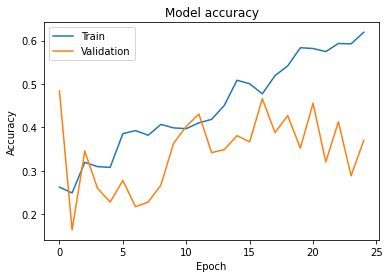

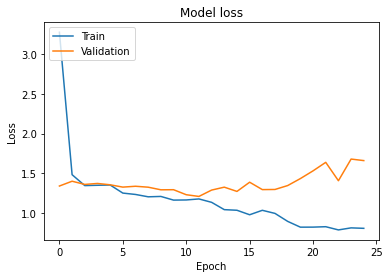

In [39]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on the test data**

In [40]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate([test_video, test_meteo], test_label)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

6/6 [==============================] - 1s 134ms/step - loss: 1.5495 - accuracy: 0.4171
Test Loss: 1.549450159072876
Test Accuracy: 0.4171428680419922


**Prediction on the test dataset**

In [41]:
# Predict the test dataset
pred_label = model.predict([test_video, test_meteo])

# Convert predictions from one-hot to labels
pred_label_cat = np.argmax(pred_label, axis=1)
true_label_cat = np.argmax(test_label, axis=1)

print(classification_report(true_label_cat.flatten(), pred_label_cat.flatten()))

6/6 [==============================] - 2s 139ms/step
              precision    recall  f1-score   support

           0       0.56      0.60      0.58        91
           1       0.26      0.24      0.25        46
           2       0.30      0.25      0.27        28
           3       0.00      0.00      0.00        10

    accuracy                           0.42       175
   macro avg       0.28      0.27      0.28       175
weighted avg       0.41      0.42      0.41       175



**Confusion Matrix**

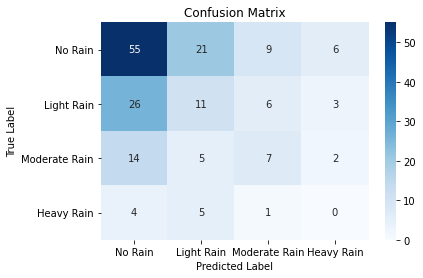

In [42]:
conmat = confusion_matrix(true_label_cat.flatten(), pred_label_cat.flatten())
sns.heatmap(conmat, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [43]:
# Assuming your model is trained and `all_meteo_seq_list`, `all_video_list`, and `all_label_list` are prepared
# Prepare the test data (replace with actual test data if needed)
# Here we use the last entry in the lists, but you can use any data for testing

test_meteo_seq = all_meteo_seq_list[-1]  # Or use your test set
test_video_seq = all_video_list[-1]  # Or use your test set
test_labels = all_label_list[-1]  # Actual labels (ground truth)

# Make sure both inputs are NumPy arrays
test_meteo_seq = np.array(test_meteo_seq)
test_video_seq = np.array(test_video_seq)

# Get the model's predictions
predictions = model.predict([test_video_seq, test_meteo_seq])

# If you want to get the predicted class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Assuming the labels are categorical (e.g., one-hot encoded), get the actual labels
actual_classes = np.argmax(test_labels, axis=-1)

# Display the actual labels and predicted labels side by side
for actual, predicted in zip(actual_classes, predicted_classes):
    print(f"Actual label: {actual} | Predicted label: {predicted}")


6/6 [==============================] - 1s 127ms/step
Actual label: 0 | Predicted label: 1
Actual label: 0 | Predicted label: 1
Actual label: 0 | Predicted label: 1
Actual label: 0 | Predicted label: 0
Actual label: 3 | Predicted label: 0
Actual label: 1 | Predicted label: 0
Actual label: 1 | Predicted label: 0
Actual label: 1 | Predicted label: 1
Actual label: 0 | Predicted label: 1
Actual label: 3 | Predicted label: 1
Actual label: 0 | Predicted label: 1
Actual label: 0 | Predicted label: 1
Actual label: 1 | Predicted label: 1
Actual label: 2 | Predicted label: 2
Actual label: 0 | Predicted label: 1
Actual label: 1 | Predicted label: 0
Actual label: 2 | Predicted label: 0
Actual label: 1 | Predicted label: 3
Actual label: 2 | Predicted label: 3
Actual label: 0 | Predicted label: 3
Actual label: 2 | Predicted label: 3
Actual label: 1 | Predicted label: 3
Actual label: 0 | Predicted label: 3
Actual label: 1 | Predicted label: 3
Actual label: 0 | Predicted label: 3
Actual label: 0 | Pred

In [44]:
# Assuming your model is trained and `all_meteo_seq_list`, `all_video_list`, and `all_label_list` are prepared
# Prepare the test data (replace with actual test data if needed)
# Here we use the last entry in the lists, but you can use any data for testing

test_meteo_seq = all_meteo_seq_list[-1]  # Or use your test set
test_video_seq = all_video_list[-1]  # Or use your test set
test_labels = all_label_list[-1]  # Actual labels (ground truth)

# Make sure both inputs are NumPy arrays
test_meteo_seq = np.array(test_meteo_seq)
test_video_seq = np.array(test_video_seq)

# Get the model's predictions
predictions = model.predict([test_video_seq, test_meteo_seq])

# If you want to get the predicted class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Assuming the labels are categorical (e.g., one-hot encoded), get the actual labels
actual_classes = np.argmax(test_labels, axis=-1)

# Initialize a dictionary to store the number of correct predictions for each class
correct_class_predictions = {i: {'correct': 0, 'total': 0} for i in range(predictions.shape[-1])}

# Initialize a dictionary to track specific misclassifications (like predicting 2 for 1)
misclassified_pairs = {(1, 2): 0}  # Misclassifications where actual is 1 and predicted is 2

# Compare each prediction with the actual label and count the correct predictions for each class
for actual, predicted in zip(actual_classes, predicted_classes):
    correct_class_predictions[actual]['total'] += 1
    if actual == predicted:
        correct_class_predictions[actual]['correct'] += 1
    else:
        # Track misclassification of actual 1 as predicted 2
        if (actual, predicted) == (1, 2):
            misclassified_pairs[(1, 2)] += 1

# Print the correct predictions for each class
for class_label, counts in correct_class_predictions.items():
    correct = counts['correct']
    total = counts['total']
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"Class {class_label}: Correct: {correct} / Total: {total} | Accuracy: {accuracy:.2f}%")

# Print the number of misclassifications where class 1 was predicted as class 2
print(f"Misclassified (Actual 1 -> Predicted 2): {misclassified_pairs[(1, 2)]}")


6/6 [==============================] - 1s 149ms/step
Class 0: Correct: 55 / Total: 91 | Accuracy: 60.44%
Class 1: Correct: 11 / Total: 46 | Accuracy: 23.91%
Class 2: Correct: 7 / Total: 28 | Accuracy: 25.00%
Class 3: Correct: 0 / Total: 10 | Accuracy: 0.00%
Misclassified (Actual 1 -> Predicted 2): 6


-----

## Hybrid Model 2

Model Architecture
- One CNN layer
- Three RNN LSTM layers, with verying units through out layers and activations as desired
- Also, added dropouts and BatchNormalization

In [45]:
# Define CNN input
cnn_input = Input(shape=(9, 64, 64, 1))

# CNN Model
cnn = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same')(cnn_input)
cnn = BatchNormalization()(cnn)
cnn = MaxPooling3D(pool_size=(2, 2, 2))(cnn)
cnn = Dropout(0.20)(cnn)
cnn = Flatten()(cnn)
cnn_output = Dense(32, activation='relu')(cnn)

# Define RNN input
rnn_input = Input(shape=(7, 7))

# RNN Model
rnn = LSTM(128, return_sequences=True, activation='relu')(rnn_input)
rnn = BatchNormalization()(rnn)
rnn = Dropout(0.30)(rnn)
rnn = LSTM(64, return_sequences=True, activation='relu')(rnn)
rnn = BatchNormalization()(rnn)
rnn = Dropout(0.20)(rnn)
rnn = LSTM(32, return_sequences=False, activation='relu')(rnn)
rnn = BatchNormalization()(rnn)
rnn = Dropout(0.10)(rnn)
rnn_output = Dense(24, activation='relu')(rnn)

# Concatenate CNN and RNN outputs
concatenated = Concatenate()([cnn_output, rnn_output])

# Final dense layers
final_dense = Dense(32, activation='relu')(concatenated)
final_output = Dense(4, activation='softmax')(final_dense)

# Model assembly
model = Model(inputs=[cnn_input, rnn_input], outputs=final_output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [46]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 7, 7)]               0         []                            
                                                                                                  
 lstm_3 (LSTM)               (None, 7, 128)               69632     ['input_4[0][0]']             
                                                                                                  
 batch_normalization_5 (Bat  (None, 7, 128)               512       ['lstm_3[0][0]']              
 chNormalization)                                                                                 
                                                                                                  
 dropout_1 (Dropout)         (None, 7, 128)               0         ['batch_normalization_5[

**Model Fitting**

In [47]:
history = model.fit(
    [train_video, train_meteo],
    train_label,                
    epochs=25,                 
    batch_size=32,               
    class_weight=class_weight_dict,
    validation_split=0.3
)

Epoch 1/25
31/31 [==============================] - 73s 2s/step - loss: 3.5672 - accuracy: 0.2752 - val_loss: 1.8858 - val_accuracy: 0.5819
Epoch 2/25
31/31 [==============================] - 66s 2s/step - loss: 1.4197 - accuracy: 0.3445 - val_loss: 1.1820 - val_accuracy: 0.5677
Epoch 3/25
31/31 [==============================] - 65s 2s/step - loss: 1.3808 - accuracy: 0.2620 - val_loss: 1.3930 - val_accuracy: 0.2850
Epoch 4/25
31/31 [==============================] - 66s 2s/step - loss: 1.3570 - accuracy: 0.3201 - val_loss: 1.3711 - val_accuracy: 0.2922
Epoch 5/25
31/31 [==============================] - 67s 2s/step - loss: 1.3366 - accuracy: 0.3282 - val_loss: 1.2637 - val_accuracy: 0.5059
Epoch 6/25
31/31 [==============================] - 66s 2s/step - loss: 1.2921 - accuracy: 0.4047 - val_loss: 1.2687 - val_accuracy: 0.5582
Epoch 7/25
31/31 [==============================] - 66s 2s/step - loss: 1.2759 - accuracy: 0.4047 - val_loss: 1.2211 - val_accuracy: 0.5796
Epoch 8/25
31/31 [==

**Plots for training & validation accuracy & loss values**

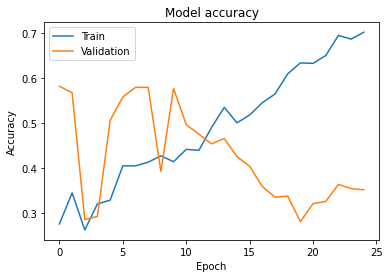

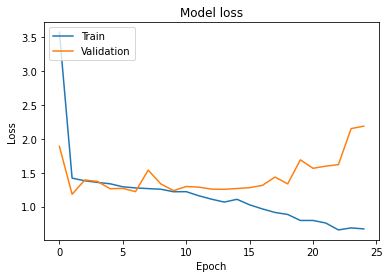

In [48]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on the test data**

In [49]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate([test_video, test_meteo], test_label)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

6/6 [==============================] - 1s 152ms/step - loss: 1.9832 - accuracy: 0.3543
Test Loss: 1.9832297563552856
Test Accuracy: 0.35428571701049805


**Prediction on the test dataset**

In [50]:
# Predict the test dataset
pred_label = model.predict([test_video, test_meteo])

# Convert predictions from one-hot to labels
pred_label_cat = np.argmax(pred_label, axis=1)
true_label_cat = np.argmax(test_label, axis=1)

print(classification_report(true_label_cat.flatten(), pred_label_cat.flatten()))

6/6 [==============================] - 1s 127ms/step
              precision    recall  f1-score   support

           0       0.58      0.48      0.53        91
           1       0.22      0.17      0.20        46
           2       0.16      0.32      0.22        28
           3       0.12      0.10      0.11        10

    accuracy                           0.35       175
   macro avg       0.27      0.27      0.26       175
weighted avg       0.39      0.35      0.37       175



**Confusion Matrix**

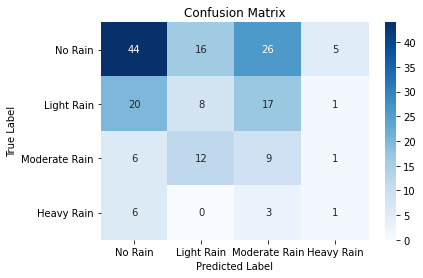

In [51]:
conmat = confusion_matrix(true_label_cat.flatten(), pred_label_cat.flatten())
sns.heatmap(conmat, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [52]:
# Assuming your model is trained and `all_meteo_seq_list`, `all_video_list`, and `all_label_list` are prepared
# Prepare the test data (replace with actual test data if needed)
# Here we use the last entry in the lists, but you can use any data for testing

test_meteo_seq = all_meteo_seq_list[-1]  # Or use your test set
test_video_seq = all_video_list[-1]  # Or use your test set
test_labels = all_label_list[-1]  # Actual labels (ground truth)

# Make sure both inputs are NumPy arrays
test_meteo_seq = np.array(test_meteo_seq)
test_video_seq = np.array(test_video_seq)

# Get the model's predictions
predictions = model.predict([test_video_seq, test_meteo_seq])

# If you want to get the predicted class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Assuming the labels are categorical (e.g., one-hot encoded), get the actual labels
actual_classes = np.argmax(test_labels, axis=-1)

# Initialize a dictionary to store the number of correct predictions for each class
correct_class_predictions = {i: {'correct': 0, 'total': 0} for i in range(predictions.shape[-1])}

# Initialize a dictionary to track specific misclassifications (like predicting 2 for 1)
misclassified_pairs = {(1, 2): 0}  # Misclassifications where actual is 1 and predicted is 2

# Compare each prediction with the actual label and count the correct predictions for each class
for actual, predicted in zip(actual_classes, predicted_classes):
    correct_class_predictions[actual]['total'] += 1
    if actual == predicted:
        correct_class_predictions[actual]['correct'] += 1
    else:
        # Track misclassification of actual 1 as predicted 2
        if (actual, predicted) == (1, 2):
            misclassified_pairs[(1, 2)] += 1

# Print the correct predictions for each class
for class_label, counts in correct_class_predictions.items():
    correct = counts['correct']
    total = counts['total']
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"Class {class_label}: Correct: {correct} / Total: {total} | Accuracy: {accuracy:.2f}%")

# Print the number of misclassifications where class 1 was predicted as class 2
print(f"Misclassified (Actual 1 -> Predicted 2): {misclassified_pairs[(1, 2)]}")


6/6 [==============================] - 1s 151ms/step
Class 0: Correct: 44 / Total: 91 | Accuracy: 48.35%
Class 1: Correct: 8 / Total: 46 | Accuracy: 17.39%
Class 2: Correct: 9 / Total: 28 | Accuracy: 32.14%
Class 3: Correct: 1 / Total: 10 | Accuracy: 10.00%
Misclassified (Actual 1 -> Predicted 2): 17


-----

# Hybrid Model 3

Model Architecture
- One CNN layer
- Two RNN LSTM layers, with verying units through out layers and activations as desired
- BatchNormalization and no dropouts this time

In [53]:
# CNN Model
cnn_input = Input(shape=(9, 64, 64, 1))
cnn = Conv3D(filters=32, kernel_size=(3, 3, 3), padding='same')(cnn_input)
cnn = BatchNormalization()(cnn)
cnn = MaxPooling3D(pool_size=(2, 2, 2))(cnn)

cnn = Flatten()(cnn)
cnn_output = Dense(16, activation='relu')(cnn)

# RNN Model
rnn_input = Input(shape=(7, 7))
rnn = LSTM(64, return_sequences=True)(rnn_input)
rnn = BatchNormalization()(rnn)
rnn = LSTM(32, return_sequences=False)(rnn)
rnn = BatchNormalization()(rnn)
rnn_output = Dense(24, activation='relu')(rnn)

# Concatenation and final layers
concatenated = Concatenate()([cnn_output, rnn_output])

final_dense = Dense(32, activation='relu')(concatenated)
final_output = Dense(4, activation='softmax')(final_dense)

# Final model assembly
model = Model(inputs=[cnn_input, rnn_input], outputs=final_output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [54]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 9, 64, 64, 1)]       0         []                            
                                                                                                  
 input_6 (InputLayer)        [(None, 7, 7)]               0         []                            
                                                                                                  
 conv3d_2 (Conv3D)           (None, 9, 64, 64, 32)        896       ['input_5[0][0]']             
                                                                                                  
 lstm_6 (LSTM)               (None, 7, 64)                18432     ['input_6[0][0]']             
                                                                                            

**Model Fitting**

In [55]:
history = model.fit(
    [train_video, train_meteo],
    train_label,                
    epochs=40,                 
    batch_size=32,               
    class_weight=class_weight_dict,
    validation_split=0.2
)

Epoch 1/40
36/36 [==============================] - 78s 2s/step - loss: 3.5810 - accuracy: 0.3363 - val_loss: 1.4189 - val_accuracy: 0.1530
Epoch 2/40
36/36 [==============================] - 74s 2s/step - loss: 1.3776 - accuracy: 0.3417 - val_loss: 1.4240 - val_accuracy: 0.0996
Epoch 3/40
36/36 [==============================] - 73s 2s/step - loss: 1.3004 - accuracy: 0.3515 - val_loss: 1.4210 - val_accuracy: 0.1352
Epoch 4/40
36/36 [==============================] - 73s 2s/step - loss: 1.2814 - accuracy: 0.3577 - val_loss: 1.4335 - val_accuracy: 0.0676
Epoch 5/40
36/36 [==============================] - 73s 2s/step - loss: 1.2785 - accuracy: 0.3756 - val_loss: 1.4348 - val_accuracy: 0.1601
Epoch 6/40
36/36 [==============================] - 74s 2s/step - loss: 1.2566 - accuracy: 0.3684 - val_loss: 1.4288 - val_accuracy: 0.1281
Epoch 7/40
36/36 [==============================] - 73s 2s/step - loss: 1.2338 - accuracy: 0.3675 - val_loss: 1.4332 - val_accuracy: 0.1495
Epoch 8/40
36/36 [==

**Plots for training & validation accuracy & loss values**

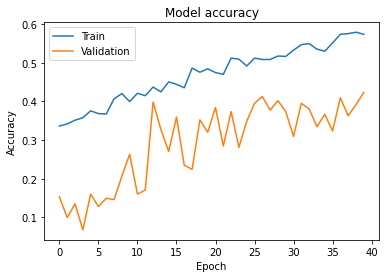

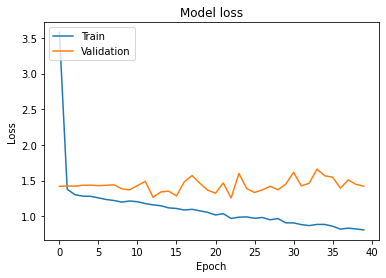

In [56]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on the test data**

In [57]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate([test_video, test_meteo], test_label)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

6/6 [==============================] - 1s 139ms/step - loss: 1.7024 - accuracy: 0.3657
Test Loss: 1.7023824453353882
Test Accuracy: 0.36571428179740906


**Prediction on the test dataset**

In [58]:
# Predict the test dataset
pred_label = model.predict([test_video, test_meteo])

# Convert predictions from one-hot to labels
pred_label_cat = np.argmax(pred_label, axis=1)
true_label_cat = np.argmax(test_label, axis=1)

print(classification_report(true_label_cat.flatten(), pred_label_cat.flatten()))

6/6 [==============================] - 2s 134ms/step
              precision    recall  f1-score   support

           0       0.54      0.56      0.55        91
           1       0.19      0.15      0.17        46
           2       0.19      0.18      0.18        28
           3       0.06      0.10      0.07        10

    accuracy                           0.37       175
   macro avg       0.24      0.25      0.24       175
weighted avg       0.37      0.37      0.36       175



**Confusion Matrix**

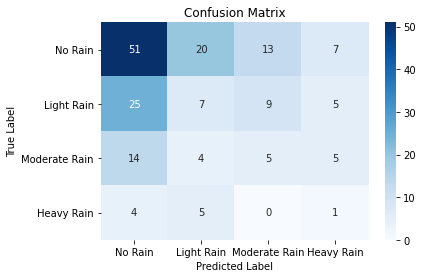

In [59]:
conmat = confusion_matrix(true_label_cat.flatten(), pred_label_cat.flatten())
sns.heatmap(conmat, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [60]:
# Assuming your model is trained and `all_meteo_seq_list`, `all_video_list`, and `all_label_list` are prepared
# Prepare the test data (replace with actual test data if needed)
# Here we use the last entry in the lists, but you can use any data for testing

test_meteo_seq = all_meteo_seq_list[-1]  # Or use your test set
test_video_seq = all_video_list[-1]  # Or use your test set
test_labels = all_label_list[-1]  # Actual labels (ground truth)

# Make sure both inputs are NumPy arrays
test_meteo_seq = np.array(test_meteo_seq)
test_video_seq = np.array(test_video_seq)

# Get the model's predictions
predictions = model.predict([test_video_seq, test_meteo_seq])

# If you want to get the predicted class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Assuming the labels are categorical (e.g., one-hot encoded), get the actual labels
actual_classes = np.argmax(test_labels, axis=-1)

# Initialize a dictionary to store the number of correct predictions for each class
correct_class_predictions = {i: {'correct': 0, 'total': 0} for i in range(predictions.shape[-1])}

# Initialize a dictionary to track specific misclassifications (like predicting 2 for 1)
misclassified_pairs = {(1, 2): 0}  # Misclassifications where actual is 1 and predicted is 2

# Compare each prediction with the actual label and count the correct predictions for each class
for actual, predicted in zip(actual_classes, predicted_classes):
    correct_class_predictions[actual]['total'] += 1
    if actual == predicted:
        correct_class_predictions[actual]['correct'] += 1
    else:
        # Track misclassification of actual 1 as predicted 2
        if (actual, predicted) == (1, 2):
            misclassified_pairs[(1, 2)] += 1

# Print the correct predictions for each class
for class_label, counts in correct_class_predictions.items():
    correct = counts['correct']
    total = counts['total']
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"Class {class_label}: Correct: {correct} / Total: {total} | Accuracy: {accuracy:.2f}%")

# Print the number of misclassifications where class 1 was predicted as class 2
print(f"Misclassified (Actual 1 -> Predicted 2): {misclassified_pairs[(1, 2)]}")


6/6 [==============================] - 1s 140ms/step
Class 0: Correct: 51 / Total: 91 | Accuracy: 56.04%
Class 1: Correct: 7 / Total: 46 | Accuracy: 15.22%
Class 2: Correct: 5 / Total: 28 | Accuracy: 17.86%
Class 3: Correct: 1 / Total: 10 | Accuracy: 10.00%
Misclassified (Actual 1 -> Predicted 2): 9


-----

## Conclusion:
**The hybrid model 2 with One CNN layer and 3 RNN LSTM worked well to predict one day in advance covering all four classes, although the accuracies are not that great because of less data after doing aggregations in daily level**